## TTS(Text To Speech)
- 감지된 이미지 관련 음성으로 들려주기
- <-> STT(Speech To Text)
- 유기 동물을 탐지 후 보호소 안내 메세지 음성으로 출력

In [1]:
!pip install ultralytics opencv-python playsound==1.2.2
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 10.3 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.3
    Uninstalling click-8.3.3:
      Successfully uninstalled click-8.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [3]:
# TTS 연습
from gtts import gTTS
from IPython.display import Audio # jupyter notebook 용
from playsound import playsound   # local 편집기용(vsc...)

def speakFunc(message):
  tts = gTTS(text=message, lang='ko')
  tts.save('yolo5test.mp3') # 음성파일로 저장
  return Audio('yolo5test.mp3', autoplay=True) # 재생(Jupyter)
  # playsound('yolo5test.mp3') # 재생(local)

message = """삼성전자 노사, 2차 사후조정 시작
DS부문·사업부 성과급 배분 '이견'
초기업노조 내 '노조 분리' 목소리도
중노위 조정안 제시 여부가 '관건'
"""
speakFunc(message)

In [10]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from gtts import gTTS
from IPython.display import Audio # jupyter notebook 용
from playsound import playsound # local 편집기용(vsc ...)
from datetime import datetime

# 보호소 정보 안내(텍스트 + 음성 재생을위한 함수 생성)
def show_shelter_info_func(region, shelters, detected_info):
  shelters_info = shelters.get(region, shelters['기본'])
  pet_summary = f"{detected_info['count']}마리 ({', '.join(detected_info['labels'])})"

  message = (
      f"유기 동물 탐지 결과 \n"
      f" - 탐지된 동물 수 : {detected_info['count']}\n"
      f" - 종류 : {detected_info['labels']}\n\n"
      f"{region} 지역 보호소 정보 :\n{shelters_info}"

  )
  print('보호소 정보 :',message)

  # 음성 안내
  try :
    tts = gTTS(
        text=f"""{region} 지역에 유기된 {pet_summary}가 감지 되었습니다.
                  가까운 보호소는 {shelters_info} 입니다.
        """, lang='ko')
    tts.save('yolo5shelter.mp3')
    display(Audio('yolo5shelter.mp3', autoplay=True))

  except Exception as e:
    print(f'음성 안내 실패 : {e}')


# 유기 동물을 만났을때 show_shelter_info_func 함수 실행
def handle_stary_pet_func(region, shelters, detected_info):
  print("유기 동물로 추정 됨")
  show_shelter_info_func(region, shelters, detected_info)

region = '테헤란로 사거리 삼원빌딩 앞'
shelters = {
    '서울':'서울 유기동물 보호센터:02-1234-5678',
    '기본':'전국 유기동물 보호센터:1577-8888'
}
detected_info = {
    "count":3,
    "labels":["호랑이","사자","코끼리"]
}

handle_stary_pet_func(region, shelters, detected_info)

유기 동물로 추정 됨
보호소 정보 : 유기 동물 탐지 결과 
 - 탐지된 동물 수 : 3
 - 종류 : ['호랑이', '사자', '코끼리']

테헤란로 사거리 삼원빌딩 앞 지역 보호소 정보 :
전국 유기동물 보호센터:1577-8888



0: 480x640 1 cat, 1 dog, 208.3ms
Speed: 10.6ms preprocess, 208.3ms inference, 4.7ms postprocess per image at shape (1, 3, 480, 640)


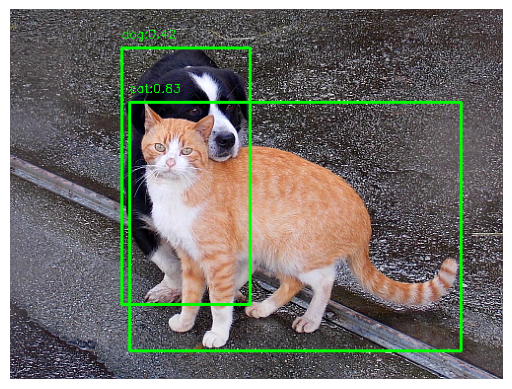


유기동물 탐지 결과 : 
 - 댕댕이
 - 냥냥이
탐지 결과가 yolo5log.txt에 저장됨
유기 동물로 추정 됨
보호소 정보 : 유기 동물 탐지 결과 
 - 탐지된 동물 수 : 2
 - 종류 : ['냥냥이', '댕댕이']

서울 지역 보호소 정보 :
서울 유가동물 보호센터:02-1234-5678


In [19]:
# 본격적으로 이미지내 객체 감지 후 함수 호출

# 탐지 정보 로그 저장
def save_detection_log_func(image_paht, detection_data):
  log_file = 'yolo5log.txt'
  now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

  with open(log_file, 'a', encoding='utf-8') as log:
    log.write(f'\n{now} 이미지:{image_paht}\n')
    log.write(f'탐지된 객체 수 :{len(detection_data)}\n')
    for d in detection_data:
      log.write(f" - {d['label']}: box={d['box']},confidence={d['confidence']:.2f}\n")
    log.write('-'*40 + '\n')
  print(f'탐지 결과가 {log_file}에 저장됨')

# 유기동물 감지 함수
def detect_pets_func(image_paht):
  pet_desc = {
      'dog':'댕댕이',
      'cat':'냥냥이'
  }
  shelters={
      '서울':'서울 유가동물 보호센터:02-1234-5678',
      '기본':'전국 유기동물 보호연합:1577-8888',
      '부산':'부산 유기동물 보호센터:051-1234-9876'
  }

  stray_keywords = ['street','road','outside','stary']

  model = YOLO('yolo11n.pt')
  image = cv2.imread(image_paht)

  if image is None:
    print('이미지를 부를 수 없어요')
    return

  results = model(image)
  detected_pets = [] # 감지된 객체 레이블 저장
  detection_data = [] # 감지된 객체 정보 저장

  for result in results:
    for box in result.boxes:
      x1,y1,x2,y2 = map(int, box.xyxy[0])
      label = result.names[int(box.cls[0])]
      confidence = box.conf[0].item()

      if label in pet_desc:
        detected_pets.append(label)
        detection_data.append({
            'label':pet_desc[label],
            'box': (x1, y1, x2, y2), # Add 'box' key with coordinates
            'x1':x1, 'y1':y1, 'x2':x2, 'y2':y2,
            'confidence':confidence
        })
        cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(image, f'{label}:{confidence:.2f}', (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)

  # 결과 이미지 저장
  output_path = 'yolo5out.jpeg'
  cv2.imwrite(output_path, image)

  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()

  if detected_pets:
    print('\n유기동물 탐지 결과 : ')
    for pet in set(detected_pets):
      print(f" - {pet_desc.get(pet, pet)}")

  # 감지정보 파일로 저장
  save_detection_log_func(image_paht, detection_data)

  # 유기동물 조건 확인
  # 감지 동물이 dog, cat이고 이미지 경로에 'street','stray'등의 키워드가 포함되면 유기동물로 판단
  if any(pet in ['dog','cat'] for pet in detected_pets) and \
          any(keyword in image_paht.lower() for keyword in stray_keywords):
    detected_info = {
        'count':len(detection_data),
        'labels' : sorted(set(d['label'] for d in detection_data))
    }

    # 유기 동물로 판단되었으므로 보호소 정보를 음성 + 텍스트로 안내
    handle_stary_pet_func(region='서울', shelters=shelters, detected_info=detected_info)

  else :
    print("유기 동물이 감지 되지 않았어요")
detect_pets_func("street_ani.jpeg")